# Calculate Errors

### 450 nm

In [2]:
import os
import sys
import numpy as np
import torch
from scipy.ndimage import zoom
from torch import nn
import pandas as pd


print("Post processing 450 nm:")
dataset_dir = "./dataset_450nm/"
save_dir = "./ML_result_450nm/"
seed = 324
nn_input_size = 448

print("Using seed",seed)
print("Using torch", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

np.random.seed(seed)
torch.manual_seed(seed)

def stokes_from_alphabeta(alpha,beta):
    alpha = alpha/180*np.pi
    beta = beta/180*np.pi
    result = np.zeros((alpha.shape[0],3),dtype=np.float32)
    result[:,0] = 0.5*(np.cos(4*alpha-4*beta)+np.cos(4*alpha))
    result[:,1] = 0.5*(np.sin(4*alpha)-np.sin(4*alpha-4*beta))
    result[:,2] = -np.sin(4*alpha-2*beta)
    return result

class BasicBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride= 1,expansion = 1,downsample= None):
        super(BasicBlock, self).__init__()
        # Multiplicative factor for the subsequent conv2d layer's output channels.
        # It is 1 for ResNet18 and ResNet34.
        self.expansion = expansion
        self.downsample = downsample
        self.conv1 = nn.Conv2d(
            in_channels, 
            out_channels, 
            kernel_size=3, 
            stride=stride, 
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, 
            out_channels*self.expansion, 
            kernel_size=3, 
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels*self.expansion)
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return  out
        
class ResNet18(nn.Module):
    def __init__(self,img_channels=1,block=BasicBlock,num_classes = 3):
        super(ResNet18, self).__init__()
        num_layers = 18
        layers = [2, 2, 2, 2]
        self.expansion = 1
        
        self.in_channels = 64
        # All ResNets (18 to 152) contain a Conv2d => BN => ReLU for the first
        # three layers. Here, kernel size is 7.
        self.conv1 = nn.Conv2d(
            in_channels=img_channels,
            out_channels=self.in_channels,
            kernel_size=7, 
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))
        self.fc = nn.Linear(2048*self.expansion, num_classes)
        
    def _make_layer(self,block,out_channels,blocks,stride = 1):
        downsample = None
        if stride != 1:
            """
            This should pass from `layer2` to `layer4` or 
            when building ResNets50 and above. Section 3.3 of the paper
            Deep Residual Learning for Image Recognition
            (https://arxiv.org/pdf/1512.03385v1.pdf).
            """
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, 
                    out_channels*self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False 
                ),
                nn.BatchNorm2d(out_channels * self.expansion),
            )
        layers = []
        layers.append(
            block(
                self.in_channels, out_channels, stride, self.expansion, downsample
            )
        )
        self.in_channels = out_channels * self.expansion
        for i in range(1, blocks):
            layers.append(block(
                self.in_channels,
                out_channels,
                expansion=self.expansion
            ))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # The spatial dimension of the final layer's feature 
        # map should be (7, 7) for all ResNets.
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    

print("Loading data...")
sys.stdout.flush()
fo = np.load(dataset_dir+"random_parameters.npz")
alpha_array = fo["arr_0"]
beta_array = fo["arr_1"]
all_y = stokes_from_alphabeta(alpha_array,beta_array).astype(np.float32)
all_x = np.zeros((all_y.shape[0],1,nn_input_size,nn_input_size),dtype=np.float32)
for i in range(20):
    fo = np.load(dataset_dir+"data%d.npz"%i)
    cur_imgs = fo["arr_0"]
    cur_t = fo["arr_1"]
    for j in range(100):
        all_x[i*100+j,0] = zoom(cur_imgs[j]/cur_t[j],
                                (nn_input_size/cur_imgs[j].shape[0],
                                 nn_input_size/cur_imgs[j].shape[1])).astype(np.float32)

shuffled_idx = np.arange(all_y.shape[0])
np.random.shuffle(shuffled_idx)

x_test = all_x[shuffled_idx[1800:]]
x_test_gpu = torch.from_numpy(x_test).to(device)
y_test = all_y[shuffled_idx[1800:]]

model = torch.load(save_dir+"resnet_seed324.pt")
model = model.to(device)
with torch.no_grad():
    y_pred = model(x_test_gpu).detach().to("cpu").numpy()
np.savez_compressed(save_dir+"y_testpred.npz",y_test,y_pred,x_test)

MAEs = np.mean(np.abs(y_pred-y_test),0)
MSEs = np.mean(np.square(y_pred-y_test),0)
print("MAE:",MAEs)
print("MSE:",MSEs)

Post processing 450 nm:
Using seed 324
Using torch 2.0.1+cu118
Using device: cuda
Loading data...
MAE: [0.00224898 0.0020089  0.00149142]
MSE: [1.1921040e-05 7.1801396e-06 4.1018920e-06]


### 530 nm

In [1]:
import os
import sys
import numpy as np
import torch
from scipy.ndimage import zoom
from torch import nn
import pandas as pd

print("Post processing 530 nm:")
dataset_dir = "./dataset_530nm/"
save_dir = "./ML_result_530nm/"
seed = 324
nn_input_size = 448

print("Using seed",seed)
print("Using torch", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

np.random.seed(seed)
torch.manual_seed(seed)

def stokes_from_alphabeta(alpha,beta):
    alpha = alpha/180*np.pi
    beta = beta/180*np.pi
    result = np.zeros((alpha.shape[0],3),dtype=np.float32)
    result[:,0] = 0.5*(np.cos(4*alpha-4*beta)+np.cos(4*alpha))
    result[:,1] = 0.5*(np.sin(4*alpha)-np.sin(4*alpha-4*beta))
    result[:,2] = -np.sin(4*alpha-2*beta)
    return result

class BasicBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride= 1,expansion = 1,downsample= None):
        super(BasicBlock, self).__init__()
        # Multiplicative factor for the subsequent conv2d layer's output channels.
        # It is 1 for ResNet18 and ResNet34.
        self.expansion = expansion
        self.downsample = downsample
        self.conv1 = nn.Conv2d(
            in_channels, 
            out_channels, 
            kernel_size=3, 
            stride=stride, 
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, 
            out_channels*self.expansion, 
            kernel_size=3, 
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels*self.expansion)
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return  out
        
class ResNet18(nn.Module):
    def __init__(self,img_channels=1,block=BasicBlock,num_classes = 3):
        super(ResNet18, self).__init__()
        num_layers = 18
        layers = [2, 2, 2, 2]
        self.expansion = 1
        
        self.in_channels = 64
        # All ResNets (18 to 152) contain a Conv2d => BN => ReLU for the first
        # three layers. Here, kernel size is 7.
        self.conv1 = nn.Conv2d(
            in_channels=img_channels,
            out_channels=self.in_channels,
            kernel_size=7, 
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))
        self.fc = nn.Linear(2048*self.expansion, num_classes)
        
    def _make_layer(self,block,out_channels,blocks,stride = 1):
        downsample = None
        if stride != 1:
            """
            This should pass from `layer2` to `layer4` or 
            when building ResNets50 and above. Section 3.3 of the paper
            Deep Residual Learning for Image Recognition
            (https://arxiv.org/pdf/1512.03385v1.pdf).
            """
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, 
                    out_channels*self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False 
                ),
                nn.BatchNorm2d(out_channels * self.expansion),
            )
        layers = []
        layers.append(
            block(
                self.in_channels, out_channels, stride, self.expansion, downsample
            )
        )
        self.in_channels = out_channels * self.expansion
        for i in range(1, blocks):
            layers.append(block(
                self.in_channels,
                out_channels,
                expansion=self.expansion
            ))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # The spatial dimension of the final layer's feature 
        # map should be (7, 7) for all ResNets.
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    

print("Loading data...")
sys.stdout.flush()
fo = np.load(dataset_dir+"random_parameters.npz")
alpha_array = fo["arr_0"]
beta_array = fo["arr_1"]
all_y = stokes_from_alphabeta(alpha_array,beta_array).astype(np.float32)
all_x = np.zeros((all_y.shape[0],1,nn_input_size,nn_input_size),dtype=np.float32)
for i in range(20):
    fo = np.load(dataset_dir+"data%d.npz"%i)
    cur_imgs = fo["arr_0"]
    cur_t = fo["arr_1"]
    for j in range(100):
        all_x[i*100+j,0] = zoom(cur_imgs[j]/cur_t[j],
                                (nn_input_size/cur_imgs[j].shape[0],
                                 nn_input_size/cur_imgs[j].shape[1])).astype(np.float32)

shuffled_idx = np.arange(all_y.shape[0])
np.random.shuffle(shuffled_idx)

x_test = all_x[shuffled_idx[1800:]]
x_test_gpu = torch.from_numpy(x_test).to(device)
y_test = all_y[shuffled_idx[1800:]]

model = torch.load(save_dir+"resnet_seed324.pt")
model = model.to(device)
with torch.no_grad():
    y_pred = model(x_test_gpu).detach().to("cpu").numpy()
np.savez_compressed(save_dir+"y_testpred.npz",y_test,y_pred,x_test)

MAEs = np.mean(np.abs(y_pred-y_test),0)
MSEs = np.mean(np.square(y_pred-y_test),0)
print("MAE:",MAEs)
print("MSE:",MSEs)

Post processing 530 nm:
Using seed 324
Using torch 2.0.1+cu118
Using device: cuda
Loading data...
MAE: [0.00248385 0.00215094 0.00221123]
MSE: [1.1570861e-05 8.9855303e-06 6.9033376e-06]


### 630 nm

In [1]:
import os
import sys
import numpy as np
import torch
from scipy.ndimage import zoom
from torch import nn
import pandas as pd

print("Post processing 630 nm:")
dataset_dir = "./dataset_630nm/"
save_dir = "./ML_result_630nm/"
seed = 324
nn_input_size = 448

print("Using seed",seed)
print("Using torch", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

np.random.seed(seed)
torch.manual_seed(seed)

def stokes_from_alphabeta(alpha,beta):
    alpha = alpha/180*np.pi
    beta = beta/180*np.pi
    result = np.zeros((alpha.shape[0],3),dtype=np.float32)
    result[:,0] = 0.5*(np.cos(4*alpha-4*beta)+np.cos(4*alpha))
    result[:,1] = 0.5*(np.sin(4*alpha)-np.sin(4*alpha-4*beta))
    result[:,2] = -np.sin(4*alpha-2*beta)
    return result

class BasicBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride= 1,expansion = 1,downsample= None):
        super(BasicBlock, self).__init__()
        # Multiplicative factor for the subsequent conv2d layer's output channels.
        # It is 1 for ResNet18 and ResNet34.
        self.expansion = expansion
        self.downsample = downsample
        self.conv1 = nn.Conv2d(
            in_channels, 
            out_channels, 
            kernel_size=3, 
            stride=stride, 
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, 
            out_channels*self.expansion, 
            kernel_size=3, 
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels*self.expansion)
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return  out
        
class ResNet18(nn.Module):
    def __init__(self,img_channels=1,block=BasicBlock,num_classes = 3):
        super(ResNet18, self).__init__()
        num_layers = 18
        layers = [2, 2, 2, 2]
        self.expansion = 1
        
        self.in_channels = 64
        # All ResNets (18 to 152) contain a Conv2d => BN => ReLU for the first
        # three layers. Here, kernel size is 7.
        self.conv1 = nn.Conv2d(
            in_channels=img_channels,
            out_channels=self.in_channels,
            kernel_size=7, 
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))
        self.fc = nn.Linear(2048*self.expansion, num_classes)
        
    def _make_layer(self,block,out_channels,blocks,stride = 1):
        downsample = None
        if stride != 1:
            """
            This should pass from `layer2` to `layer4` or 
            when building ResNets50 and above. Section 3.3 of the paper
            Deep Residual Learning for Image Recognition
            (https://arxiv.org/pdf/1512.03385v1.pdf).
            """
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, 
                    out_channels*self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False 
                ),
                nn.BatchNorm2d(out_channels * self.expansion),
            )
        layers = []
        layers.append(
            block(
                self.in_channels, out_channels, stride, self.expansion, downsample
            )
        )
        self.in_channels = out_channels * self.expansion
        for i in range(1, blocks):
            layers.append(block(
                self.in_channels,
                out_channels,
                expansion=self.expansion
            ))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # The spatial dimension of the final layer's feature 
        # map should be (7, 7) for all ResNets.
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    

print("Loading data...")
sys.stdout.flush()
fo = np.load(dataset_dir+"random_parameters.npz")
alpha_array = fo["arr_0"]
beta_array = fo["arr_1"]
all_y = stokes_from_alphabeta(alpha_array,beta_array).astype(np.float32)
all_x = np.zeros((all_y.shape[0],1,nn_input_size,nn_input_size),dtype=np.float32)
for i in range(20):
    fo = np.load(dataset_dir+"data%d.npz"%i)
    cur_imgs = fo["arr_0"]
    cur_t = fo["arr_1"]
    for j in range(100):
        all_x[i*100+j,0] = zoom(cur_imgs[j]/cur_t[j],
                                (nn_input_size/cur_imgs[j].shape[0],
                                 nn_input_size/cur_imgs[j].shape[1])).astype(np.float32)

shuffled_idx = np.arange(all_y.shape[0])
np.random.shuffle(shuffled_idx)

x_test = all_x[shuffled_idx[1800:]]
x_test_gpu = torch.from_numpy(x_test).to(device)
y_test = all_y[shuffled_idx[1800:]]

model = torch.load(save_dir+"resnet_seed324.pt")
model = model.to(device)
with torch.no_grad():
    y_pred = model(x_test_gpu).detach().to("cpu").numpy()
np.savez_compressed(save_dir+"y_testpred.npz",y_test,y_pred,x_test)

MAEs = np.mean(np.abs(y_pred-y_test),0)
MSEs = np.mean(np.square(y_pred-y_test),0)
print("MAE:",MAEs)
print("MSE:",MSEs)

Post processing 630 nm:
Using seed 324
Using torch 2.0.1+cu118
Using device: cuda
Loading data...
MAE: [0.002479   0.00242386 0.00186556]
MSE: [1.4645945e-05 1.0217156e-05 7.4282266e-06]


# Visualize

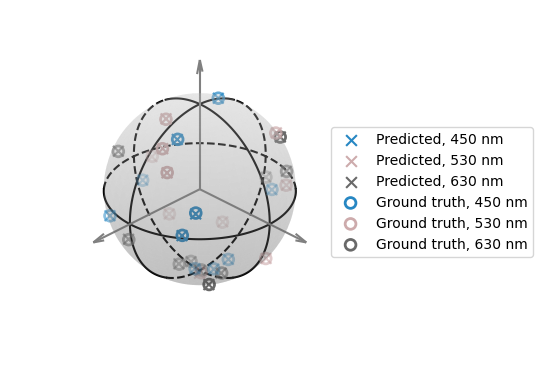

In [1]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
from itertools import product, combinations
import matplotlib.pyplot as plt
import numpy as np

fo = np.load("./ML_result_450nm/y_testpred.npz")
y_test450 = fo["arr_0"]
y_pred450 = fo["arr_1"]
x_test450 = fo["arr_2"]
fo = np.load("./ML_result_530nm/y_testpred.npz")
y_test530 = fo["arr_0"]
y_pred530 = fo["arr_1"]
x_test530 = fo["arr_2"]
fo = np.load("./ML_result_630nm/y_testpred.npz")
y_test630 = fo["arr_0"]
y_pred630 = fo["arr_1"]
x_test630 = fo["arr_2"]


colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# Make surface data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = 1 * np.outer(np.cos(u), np.sin(v))
y = 1 * np.outer(np.sin(u), np.sin(v))
z = 1 * np.outer(np.ones(np.size(u)), np.cos(v))
# Plot the surface and axis
ax.quiver([0,0,0],[0,0,0],[0,0,0],[1.5,0,0],[0,1.5,0],[0,0,1.5],color="gray",arrow_length_ratio=0.1)
ax.plot_surface(x, y, z,alpha=0.2,color="lightgray")
ax.plot3D(np.sin(v-np.pi/4),np.cos(v-np.pi/4),0,c="black")
ax.plot3D(np.sin(v-np.pi/4+np.pi),np.cos(v-np.pi/4+np.pi),0,linestyle="--",c="black")
ax.plot3D(np.sin(v-np.pi/6),np.zeros_like(v),np.cos(v-np.pi/6),c="black")
ax.plot3D(np.sin(v-np.pi/6+np.pi),np.zeros_like(v),np.cos(v-np.pi/6+np.pi),linestyle="--",c="black")
ax.plot3D(np.zeros_like(v),np.sin(v-np.pi/6),np.cos(v-np.pi/6),c="black")
ax.plot3D(np.zeros_like(v),np.sin(v-np.pi/6+np.pi),np.cos(v-np.pi/6+np.pi),linestyle="--",c="black")

# Plot data
ax.scatter(y_pred450[:10,0],y_pred450[:10,1],y_pred450[:10,2],marker="x",c=colors[0],s=60,label="Predicted, 450 nm")
ax.scatter(y_pred530[10:20,0],y_pred530[10:20,1],y_pred530[10:20,2],marker="x",c=colors[3],s=60,label="Predicted, 530 nm")
ax.scatter(y_pred630[30:40,0],y_pred630[30:40,1],y_pred630[30:40,2],marker="x",c=colors[6],s=60,label="Predicted, 630 nm")

#i = 14
#ax.scatter(y_pred530[i,0],y_pred450[i,1],y_pred450[i,2],marker="s",c="red",s=60)

ax.scatter(y_test450[:10,0],y_test450[:10,1],y_test450[:10,2],s=60,ec=colors[0],fc="None",lw=2,label="Ground truth, 450 nm")
ax.scatter(y_test530[10:20,0],y_test530[10:20,1],y_test530[10:20,2],s=60,ec=colors[3],fc="None",lw=2,label="Ground truth, 530 nm")
ax.scatter(y_test630[30:40,0],y_test630[30:40,1],y_test630[30:40,2],s=60,ec=colors[6],fc="None",lw=2,label="Ground truth, 630 nm")

# Set an equal aspect ratio
ax.set_aspect('equal')
ax.set_axis_off()
ax.view_init(elev=30, azim=45, roll=0)
ax.legend(ncol=1,bbox_to_anchor=(0.85,0.7))

plt.show()
fig.savefig('ball.svg',transparent=True, bbox_inches='tight')

([], [])

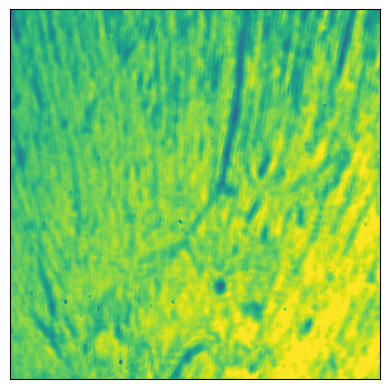

In [36]:
plot_i = [14,16,12] # top to bottom
plt.imshow(x_test530[plot_i[0],0],vmin=500,vmax=7000)
plt.xticks([])
plt.yticks([])

([], [])

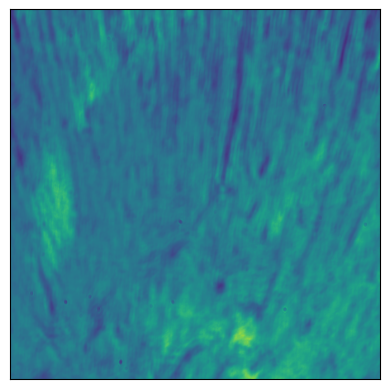

In [37]:
plt.imshow(x_test530[plot_i[1],0],vmin=500,vmax=7000)
plt.xticks([])
plt.yticks([])

([], [])

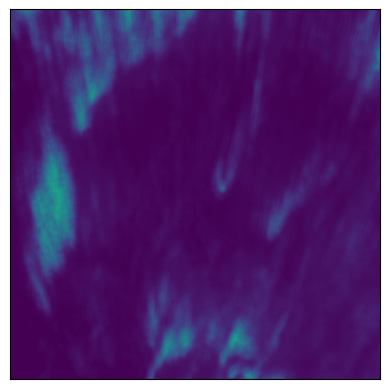

In [38]:
plt.imshow(x_test530[plot_i[2],0],vmin=500,vmax=7000)
plt.xticks([])
plt.yticks([])

# Learning Curves

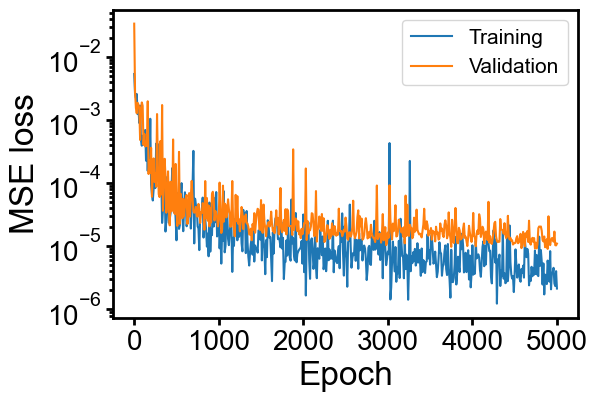

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.rcParams['font.sans-serif'] = ['Arial']

table = pd.read_csv("./ML_result_450nm/resnet_seed324.csv")
x = np.arange(table.shape[0])*10

plt.plot(x,table["train_loss"],label="Training")
plt.plot(x,table["validation_loss"],label="Validation")

plt.yscale("log")
plt.legend(fontsize=18)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.ylabel("MSE loss",fontsize=24)
plt.xlabel("Epoch",fontsize=24)
plt.legend(fontsize=15)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./450nm_curve.svg",transparent=True,bbox_inches="tight")

plt.show()

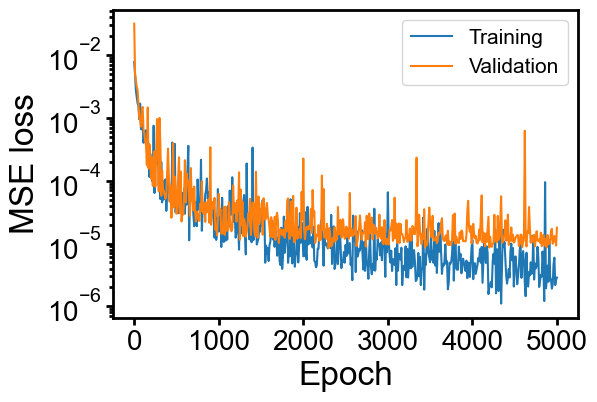

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.rcParams['font.sans-serif'] = ['Arial']

table = pd.read_csv("./ML_result_530nm/resnet_seed324.csv")
x = np.arange(table.shape[0])*10

plt.plot(x,table["train_loss"],label="Training")
plt.plot(x,table["validation_loss"],label="Validation")

plt.yscale("log")
plt.legend(fontsize=18)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.ylabel("MSE loss",fontsize=24)
plt.xlabel("Epoch",fontsize=24)
plt.legend(fontsize=15)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./530nm_curve.svg",transparent=True,bbox_inches="tight")

plt.show()

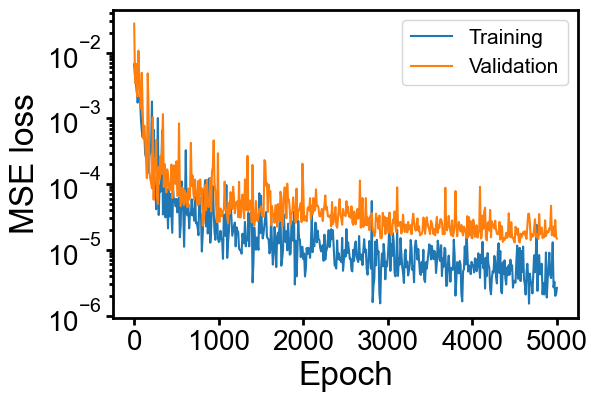

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.rcParams['font.sans-serif'] = ['Arial']

table = pd.read_csv("./ML_result_630nm/resnet_seed324.csv")
x = np.arange(table.shape[0])*10

plt.plot(x,table["train_loss"],label="Training")
plt.plot(x,table["validation_loss"],label="Validation")

plt.yscale("log")
plt.legend(fontsize=18)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.ylabel("MSE loss",fontsize=24)
plt.xlabel("Epoch",fontsize=24)
plt.legend(fontsize=15)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./630nm_curve.svg",transparent=True,bbox_inches="tight")

plt.show()

# Error summary

In [2]:
import numpy as np

MSE = np.array([[1.1921040e-05, 7.1801396e-06, 4.1018920e-06],
                [1.1570861e-05, 8.9855303e-06, 6.9033376e-06],
                [1.4645945e-05, 1.0217156e-05, 7.4282266e-06]])
RMSE = np.sqrt(np.mean(MSE,0))
RMSEs = np.sqrt(MSE)
RMSE,RMSEs

(array([0.00356548, 0.00296551, 0.00247881]),
 array([[0.00345269, 0.00267958, 0.00202531],
        [0.0034016 , 0.00299759, 0.00262742],
        [0.003827  , 0.00319643, 0.00272548]]))